GEANT4 Track Study
==================

## Units from h5 files (dumpTree)

MeV, cm, µs

## LAr Geometry

X is the drift direction, vertical \
Xmin = -425.0cm \
Xmax = 425.08cm \
Cathode = -325cm \
CRP = 325cm \
Ymin = -753.8024cm \
Ymax = 753.8024cm \
Zmin = -107.0cm \
Zmax = 2198.88cm

In [1]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
fName = '/Users/yuntse/data/lartpc_rd/gampix/g4/radiologicals/fullgeoanatruth-vd-reduced_g4_00.h5'

In [3]:
with h5py.File(fName, 'r') as f:
    # Print all top-level groups/datasets
    print(list(f.keys()))
    fS = f['segments']
    fT = f['trajectories']
    fV = f['vertices']
    print(fS.dtype)
    print(fT.dtype)
    print(fV.dtype)
    
    tempS = fS[()]
    tempT = fT[()]
    tempV = fV[()]

['segments', 'trajectories', 'vertices']
{'names': ['event_id', 'vertex_id', 'file_vertex_id', 'segment_id', 'z_end', 'traj_id', 'file_traj_id', 'tran_diff', 'z_start', 'x_end', 'y_end', 'n_electrons', 'pdg_id', 'x_start', 'y_start', 't_start', 't0_start', 't0_end', 't0', 'dx', 'long_diff', 'pixel_plane', 't_end', 'dEdx', 'dE2dx', 'dE', 'dE2', 't', 'y', 'x', 'z', 'n_photons'], 'formats': ['<u4', '<u8', '<u8', '<u4', '<f4', '<i4', '<u4', '<f4', '<f4', '<f4', '<f4', '<u4', '<i4', '<f4', '<f4', '<f4', '<f8', '<f8', '<f8', '<f4', '<f4', '<i4', '<f4', '<f4', '<f4', '<f4', '<f4', '<f4', '<f4', '<f4', '<f4', '<f4'], 'offsets': [0, 8, 16, 24, 28, 32, 36, 40, 44, 48, 52, 56, 60, 64, 68, 72, 80, 88, 96, 104, 108, 112, 116, 120, 124, 128, 132, 136, 140, 144, 148, 152], 'itemsize': 160}
{'names': ['event_id', 'vertex_id', 'file_vertex_id', 'traj_id', 'file_traj_id', 'parent_id', 'primary', 'E_start', 'pxyz_start', 'xyz_start', 't_start', 'E_end', 'pxyz_end', 'xyz_end', 't_end', 'pdg_id', 'start_pr

In [4]:
dS = pd.DataFrame(tempS)
dS

,event_id,vertex_id,file_vertex_id,segment_id,z_end,traj_id,file_traj_id,tran_diff,z_start,x_end,...,t_end,dEdx,dE2dx,dE,dE2,t,y,x,z,n_photons
0,0,2166,2166,0,98.670486,2166,2166,0.0,98.706284,348.101868,...,0.0,0.063558,0.0,0.003178,0.0,0.0,-438.227661,348.086365,98.688385,0.0
1,0,2166,2166,1,98.668915,2168,2168,0.0,98.670486,348.104218,...,0.0,27.031174,0.0,0.089725,0.0,0.0,-438.236572,348.103027,98.669701,0.0
2,0,2166,2166,2,104.624596,2167,2167,0.0,104.624336,342.946564,...,0.0,50.987686,0.0,0.038659,0.0,0.0,-435.562378,342.946808,104.624466,0.0
3,0,2165,2165,3,283.540466,2165,2165,0.0,283.542053,349.946442,...,0.0,0.063542,0.0,0.003178,0.0,0.0,-332.630402,349.921570,283.541260,0.0
4,0,2165,2165,4,283.536835,2170,2170,0.0,283.540466,349.951935,...,0.0,20.367743,0.0,0.134589,0.0,0.0,-332.627686,349.949188,283.538635,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8835149,999,3,2090281,8835149,98.972160,3,7541269,0.0,98.977150,-118.376740,...,0.0,21.503775,0.0,0.124119,0.0,0.0,-469.179474,-118.378151,98.974655,0.0
8835150,999,2,2090280,8835150,112.352966,2,7541268,0.0,112.353348,-321.522552,...,0.0,26.071560,0.0,0.095099,0.0,0.0,-448.416565,-321.521240,112.353157,0.0
8835151,999,1,2090279,8835151,43.172062,1,7541267,0.0,43.163631,111.662086,...,0.0,16.500298,0.0,0.185769,0.0,0.0,-398.363098,111.664001,43.167847,0.0
8835152,999,1,2090279,8835152,43.172062,1,7541267,0.0,43.172062,111.662086,...,0.0,0.000000,0.0,0.000002,0.0,0.0,-398.366302,111.662086,43.172062,0.0


In [5]:
dV = pd.DataFrame(tempV)
dV[dV.file_vertex_id<3]

,event_id,vertex_id,file_vertex_id,x_vert,y_vert,z_vert,t_vert,t_event
0,0,0,0,-309.160553,-476.065704,217.175781,3679.103516,0.0
1,0,1,1,-395.963318,-303.358795,207.738235,3642.347656,0.0
2,0,2,2,268.648010,-322.701965,166.737061,-1905.684326,0.0


In [6]:
dT = pd.DataFrame({
    name: tempT[name].tolist() if tempT[name].ndim > 1 else tempT[name]
    for name in tempT.dtype.names
})
dT[dT.file_vertex_id<3]

,event_id,vertex_id,file_vertex_id,traj_id,file_traj_id,parent_id,primary,E_start,pxyz_start,xyz_start,...,E_end,pxyz_end,xyz_end,t_end,pdg_id,start_process,start_subprocess,end_process,end_subprocess,dist_travel
0,0,0,0,0,0,-1,True,0.613954,"[0.0682862177491188, 0.21526359021663666, 0.25...","[-309.1605529785156, -476.0657043457031, 217.1...",...,0.510999,"[0.0, 0.0, 0.0]","[-309.1596984863281, -476.06304931640625, 217....",3679.103434,11,0,0,2,22,0.004200
1,0,1,1,1,1,-1,True,0.783480,"[-0.14507721364498138, -0.3742099404335022, 0....","[-395.96331787109375, -303.3587951660156, 207....",...,0.510999,"[-0.0, -0.0, 0.0]","[-395.9684143066406, -303.3719482421875, 207.7...",3642.347754,11,0,0,2,22,0.020858
2,0,2,2,2,2,-1,True,0.602932,"[0.20221948623657227, -0.10365697741508484, -0...","[268.64801025390625, -322.70196533203125, 166....",...,0.510999,"[0.0, -0.0, -0.0]","[268.6501770019531, -322.70306396484375, 166.7...",-1905.684382,11,0,0,2,22,0.003460


In [7]:
pdgCodes = dT.pdg_id.unique()
pdgCodes

array([        11, 1000020040,         22,        -11, 1000200430,
             2112, 1000180410, 1000180400], dtype=int32)

In [8]:
# create a dataframe for fixing the color code
particleName = np.array([ 'electron', 'alpha', 'photon', 'positron', 'Ca43', 'neutron', 
                          'Ar41', 'Ar40',
                         ])

pdgDF = pd.DataFrame({ 'pdgCode': pdgCodes, 'name': particleName })

pdgDF

,pdgCode,name
0,11,electron
1,1000020040,alpha
2,22,photon
3,-11,positron
4,1000200430,Ca43
5,2112,neutron
6,1000180410,Ar41
7,1000180400,Ar40


In [9]:
palette = plt.get_cmap("tab10").colors[:8]
colorAll = plt.get_cmap("tab10").colors[8]

# build mapping using pdgDF order
code_to_color = dict(zip(pdgDF["pdgCode"], palette))

# add to pdgDF
pdgDF["color"] = pdgDF["pdgCode"].map(code_to_color)

pdgDF

,pdgCode,name,color
0,11,electron,"(0.12156862745098039, 0.4666666666666667, 0.70..."
1,1000020040,alpha,"(1.0, 0.4980392156862745, 0.054901960784313725)"
2,22,photon,"(0.17254901960784313, 0.6274509803921569, 0.17..."
3,-11,positron,"(0.8392156862745098, 0.15294117647058825, 0.15..."
4,1000200430,Ca43,"(0.5803921568627451, 0.403921568627451, 0.7411..."
5,2112,neutron,"(0.5490196078431373, 0.33725490196078434, 0.29..."
6,1000180410,Ar41,"(0.8901960784313725, 0.4666666666666667, 0.760..."
7,1000180400,Ar40,"(0.4980392156862745, 0.4980392156862745, 0.498..."


In [9]:
# 0) create a dataframe with file_vertex_id
# dVid = dT[["file_vertex_id"]].drop_duplicates()


# 1) number of rows per file_vertex_id (in dT)
# nTracks = (
#     dT.groupby("file_vertex_id")
#     .size()
#     .reset_index(name="n_tracks")
# )

# 2) pdg_id for the primary==True row (per file_vertex_id)
# If there can be more than one primary row, this takes the first one.
# pdgPrimary = (
#     dT.loc[dT["primary"] == True, ["file_vertex_id", "pdg_id"]]
#     .drop_duplicates(subset=["file_vertex_id"])  # keep first primary per vertex
#     .rename(columns={"pdg_id": "pdg_id"})
# )

# 3) build result for all ids in df_ids (use how="inner" if you only want those present in tracks_df)
# dTPrimary = (
#     dVid[["file_vertex_id"]]
#     .drop_duplicates()
#     .merge(nTracks, on = "file_vertex_id", how = "left")
#     .merge(pdgPrimary, on = "file_vertex_id", how = "left")
# )

In [9]:
# dTPrimary

In [10]:
# dTPrimary.pdg_id.unique()

## Track features

length (travel distance), deposited energy, etc.

In [10]:
dT['dist_travel'].min(), dT['dist_travel'].max()

(7.70895014490236e-10, 9773.8896484375)

General picture of track lengths

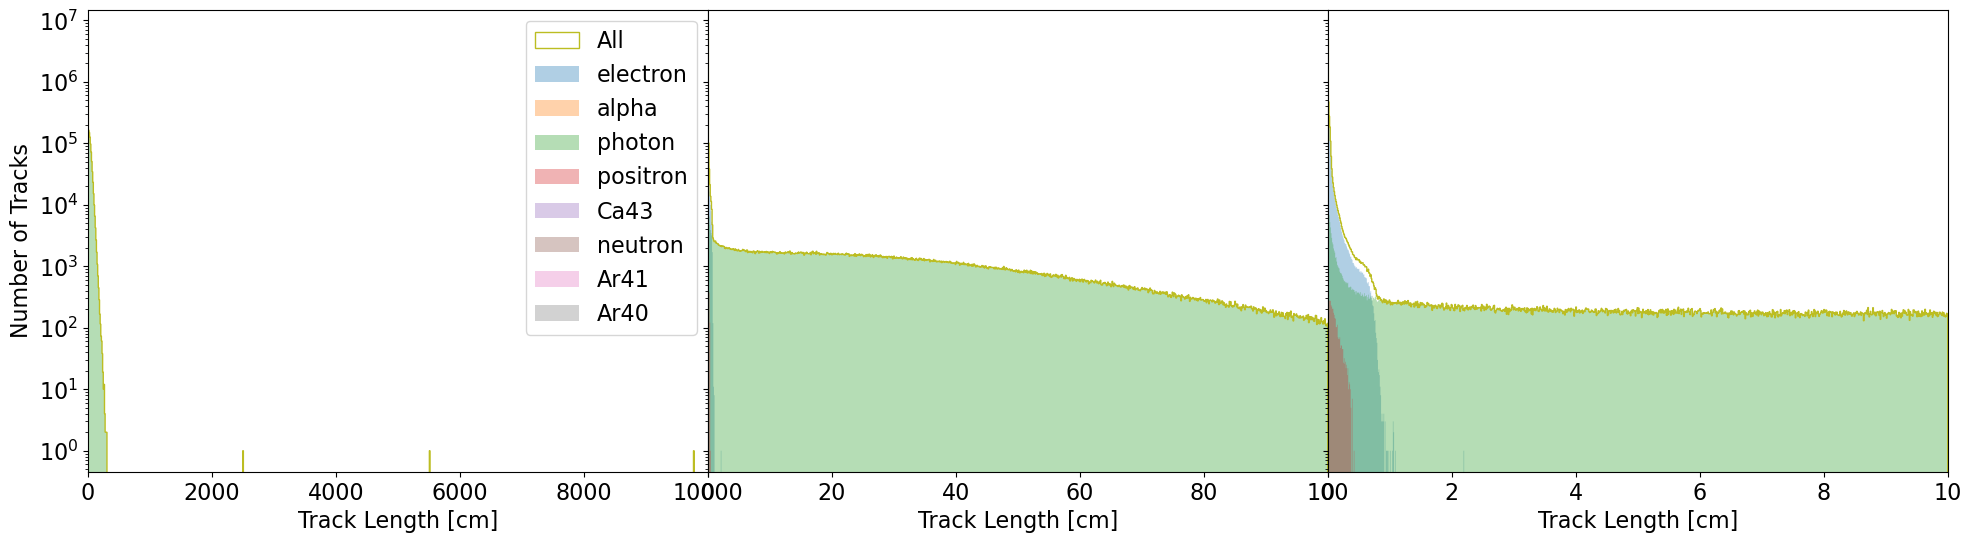

In [11]:
fig, ax = plt.subplots(1, 3, figsize = (24, 6), sharey = True)
fig.subplots_adjust(wspace = 0)  # remove gaps between panels

distBins = np.array([np.linspace(0, 10000, 1001), np.linspace(0, 100, 1001), np.linspace(0, 10, 1001)])
fonts = 16

for i in range(3):
    ax[i].hist(dT['dist_travel'], bins = distBins[i], histtype = 'step', label = 'All', color = colorAll )
    for ip in pdgDF.itertuples( index = False ):
        ax[i].hist(dT.loc[dT['pdg_id'].eq(ip.pdgCode), 'dist_travel'], bins = distBins[i], histtype = 'stepfilled', alpha = 0.35,
                   color = ip.color, label = ip.name)

        ax[i].set_xlabel('Track Length [cm]', fontsize = fonts)
        ax[i].tick_params(axis = "both", labelsize = fonts)
        ax[i].set_yscale('log')

ax[0].set_ylabel('Number of Tracks', fontsize = fonts)
ax[0].set_xlim([0, 10000])
ax[1].set_xlim([0, 100])
ax[2].set_xlim([0, 10])
ax[0].legend(fontsize = fonts)

Track length - zoom in

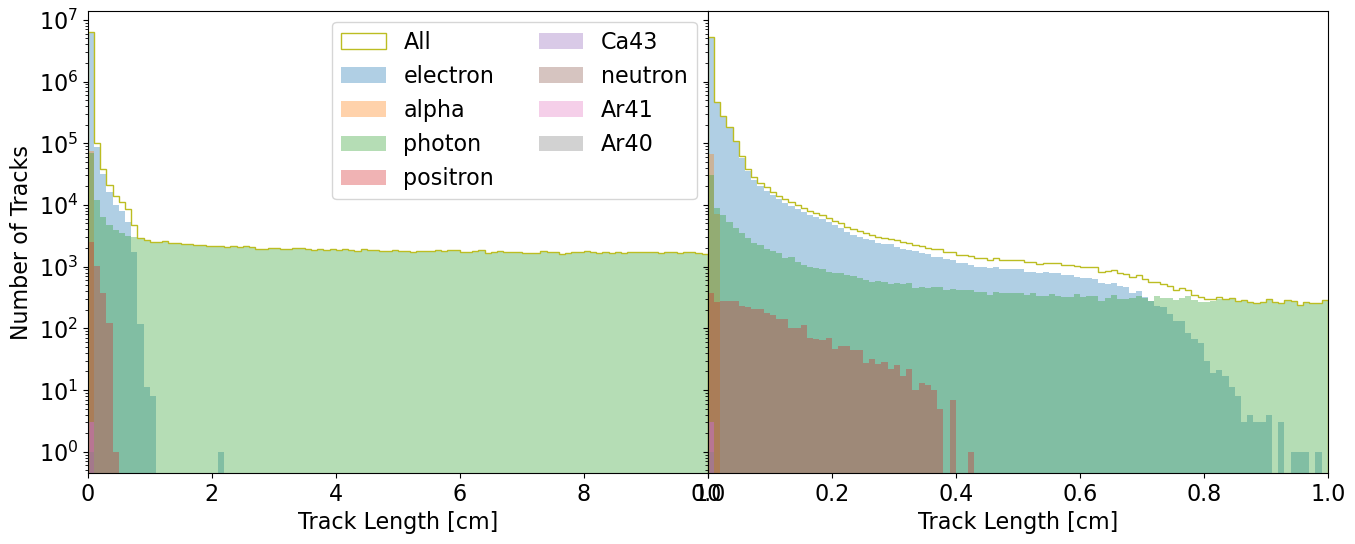

In [12]:
fig, ax = plt.subplots(1, 2, figsize = (16, 6), sharey = True)
fig.subplots_adjust(wspace = 0)  # remove gaps between panels

distBins = np.array([np.linspace(0, 10, 101), np.linspace(0, 1, 101)])
fonts = 16

for i in range(2):
    ax[i].hist(dT['dist_travel'], bins = distBins[i], histtype = 'step', label = 'All', color = colorAll)
    for ip in pdgDF.itertuples( index = False ):
        ax[i].hist(dT.loc[dT['pdg_id'].eq(ip.pdgCode), 'dist_travel'], bins = distBins[i], histtype = 'stepfilled', alpha = 0.35,
                   color = ip.color, label = ip.name)

        ax[i].set_xlabel('Track Length [cm]', fontsize = fonts)
        ax[i].tick_params(axis = "both", labelsize = fonts)
        ax[i].set_yscale('log')

ax[0].set_ylabel('Number of Tracks', fontsize = fonts)
ax[0].set_xlim([0, 10])
ax[1].set_xlim([0, 1])
ax[0].legend(ncol = 2, fontsize = fonts)

In [13]:
(dT.E_start-dT.E_end).max()

8.78515625

Deposited energy

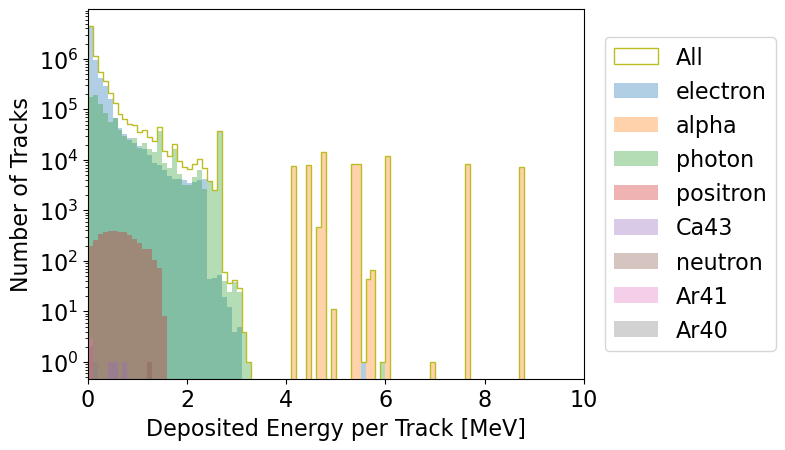

In [14]:
fig, ax = plt.subplots()

dEBins = np.linspace(0., 10., 101)
fonts = 16

ax.hist(dT['E_start'] - dT['E_end'], bins = dEBins, histtype = 'step', label = 'All', color = colorAll)
for ip in pdgDF.itertuples( index = False ):
    mask = dT["pdg_id"].eq(ip.pdgCode)
    dE = dT.loc[mask, "E_start"] - dT.loc[mask, "E_end"]
    ax.hist(dE, bins = dEBins, histtype = 'stepfilled', alpha = 0.35,
            color = ip.color, label = ip.name)

ax.set_xlabel('Deposited Energy per Track [MeV]', fontsize = fonts)
ax.tick_params(axis = "both", labelsize = fonts)
ax.set_yscale('log')

ax.set_ylabel('Number of Tracks', fontsize = fonts)
ax.set_xlim([0, 10])
ax.legend(loc = "center left", bbox_to_anchor = (1.02, 0.5), fontsize = fonts)

## Photons depositing > 1 MeV

I don't understand why there are so many photons depositing nonnegligble energy.
Here I am checking photons depositing > 1 MeV

In [15]:
photons1MeV = dT[(dT.pdg_id==22)&(dT.E_start-dT.E_end>1)]

In [16]:
photons1MeV['start_process'].unique(), photons1MeV['end_process'].unique()

(array([0, 2, 4], dtype=int32), array([2], dtype=int32))

In [17]:
photons1MeV['start_subprocess'].unique(), photons1MeV['end_subprocess'].unique()

(array([  0,  22,  13,  11,  12,   2,   5,   3,  14, 121, 131, 111],
       dtype=int32),
 array([12, 14], dtype=int32))

I am very puzzled why photons can deposit so much energy....\
Process 2 = Electromagnetic,\
Process 4 = Decay,\
Process 5 = Hadronic (not in my sample)

| ProcessType  | Subprocess | Meaning                        | Typical G4 Class                                 |
| ------------ | ---------- | ------------------------------ | ------------------------------------------------ |
| 2 – EM       | 0          | Not defined                    | —                                                |
| 2 – EM       | 1          | Coulomb scattering             | `G4CoulombScattering`                            |
| 2 – EM       | 2          | Multiple scattering            | `G4MultipleScattering`                           |
| 2 – EM       | 3          | Ionisation                     | `G4eIonisation`, `G4hIonisation`                 |
| 2 – EM       | 4          | Bremsstrahlung                 | `G4eBremsstrahlung`                              |
| 2 – EM       | 5          | Annihilation                   | `G4eplusAnnihilation`                            |
| 2 – EM       | 6          | Pair production                | `G4GammaConversionToMuons` / `G4GammaConversion` |
| 2 – EM       | 7          | Photoelectric effect           | `G4PhotoElectricEffect`                          |
| 2 – EM       | 8          | Compton scattering             | `G4ComptonScattering`                            |
| 2 – EM       | 9          | Gamma conversion               | `G4GammaConversion`                              |
| 2 – EM       | 10         | Rayleigh scattering            | `G4RayleighScattering`                           |
| 2 – EM       | 11         | Auger electron production      | `G4AugerElectron`                                |
| 2 – EM       | 12         | Atomic de-excitation           | `G4AtomicDeexcitation`                           |
| 2 – EM       | 13         | Synchrotron radiation          | `G4SynchrotronRadiation`                         |
| 2 – EM       | 14         | Cerenkov radiation             | `G4Cerenkov`                                     |
| 2 – EM       | 15         | Gamma nuclear reaction         | `G4GammaNuclearReaction`                         |
| 2 – EM       | 16         | Moller/Bhabha scattering       | `G4MollerBhabhaModel`                            |
| 2 – EM       | 17         | Photo nuclear reaction         | `G4PhotoNuclearProcess`                          |
| 2 – EM       | 18         | Muon nuclear reaction          | `G4MuonNuclearProcess`                           |
| 2 – EM       | 19         | Electron capture               | `G4ElectronCapture`                              |
| 2 – EM       | 20         | Auger cascade                  | `G4AugerCascade`                                 |
| 2 – EM       | 21         | Nuclear stopping               | `G4NuclearStopping`                              |
| 2 – EM       | 22         | Neutron EM-related interaction | —                                                |
| 4 – Decay    | 0          | Not defined                    | —                                                |
| 4 – Decay    | 1          | Particle decay                 | `G4Decay`                                        |
| 4 – Decay    | 2          | Radioactive decay              | `G4RadioactiveDecay`                             |
| 4 – Decay    | 3          | Special/general decay          | Rare / custom                                    |
| 5 – Hadronic | 0          | Not defined                    | —                                                |
| 5 – Hadronic | 11         | Hadron capture at rest         | `G4HadronCaptureProcess`                         |
| 5 – Hadronic | 12         | Neutron capture                | `G4NeutronCapture`                               |
| 5 – Hadronic | 13         | Hadron elastic                 | `G4HadronElasticProcess`                         |
| 5 – Hadronic | 14         | Fission                        | `G4HadronFissionProcess`, `G4NeutronFission`     |
| 5 – Hadronic | 15         | Elastic (generic)              | `G4ElasticProcess`                               |
| 5 – Hadronic | 21         | Inelastic (generic)            | `G4InelasticProcess`                             |
| 5 – Hadronic | 22         | Neutron inelastic              | `G4NeutronInelastic`                             |
| 5 – Hadronic | 23         | Proton inelastic               | `G4ProtonInelastic`                              |
| 5 – Hadronic | 24         | Pion inelastic                 | `G4PionInelastic`                                |
| 5 – Hadronic | 25         | Kaon inelastic                 | `G4KaonInelastic`                                |
| 5 – Hadronic | 26         | Hyperon inelastic              | `G4HyperonInelastic`                             |
| 5 – Hadronic | 27         | Anti-baryon inelastic          | `G4AntiBaryonInelastic`                          |
| 5 – Hadronic | 28         | Ion inelastic                  | `G4IonInelastic`                                 |
| 5 – Hadronic | 31         | Charge exchange                | `G4ChargeExchangeProcess`                        |
| 5 – Hadronic | 41         | Elastic at rest                | `G4ElasticAtRest`                                |
| 5 – Hadronic | 42         | Fission at rest                | `G4FissionAtRest`                                |


In [18]:
photons1MeV[photons1MeV.start_process==2]['start_subprocess'].unique()

array([22, 13, 11, 12,  2,  5,  3, 14], dtype=int32)

In [19]:
photons1MeV[photons1MeV.start_process==4]['start_subprocess'].unique()

array([121, 131, 111], dtype=int32)

## Photons' deposited energy v.s. travel length

In [20]:
import matplotlib.colors as colors

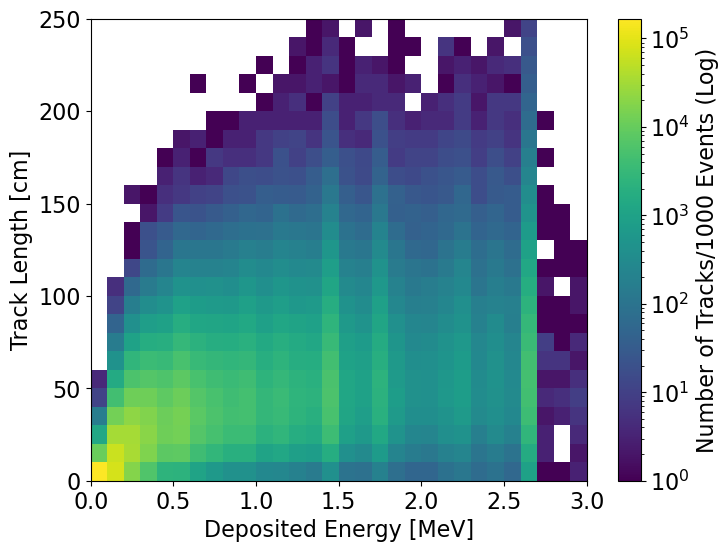

In [21]:
fig, ax = plt.subplots(figsize = (8, 6))

mask = dT["pdg_id"].eq(22)
dE = dT.loc[mask, "E_start"] - dT.loc[mask, "E_end"]
l = dT.loc[mask, 'dist_travel']
fonts = 16

h = ax.hist2d(dE, l, bins = (30, 25), range = [[0, 3.], [0, 250]], cmap = 'viridis', norm = colors.LogNorm())
ax.set_xlabel('Deposited Energy [MeV]', fontsize = fonts)
ax.set_ylabel('Track Length [cm]', fontsize = fonts)
ax.tick_params(axis = "both", labelsize = fonts)

cbar = fig.colorbar(h[3])
cbar.ax.tick_params( labelsize = fonts)     # ticks (numbers)
cbar.set_label("Number of Tracks/1000 Events (Log)", fontsize = fonts) 

## Position

In [22]:
start_x = dT['xyz_start'].str[0]
start_y = dT['xyz_start'].str[1]
start_z = dT['xyz_start'].str[2]
start_x.min(), start_x.max(), start_y.min(), start_y.max(), start_z.min(), start_z.max()

(-536.0497436523438,
 579.1588745117188,
 -785.4510498046875,
 -117.93391418457031,
 -178.95741271972656,
 467.3110046386719)

X, Y, Z of the track starting points, 10cm/bin

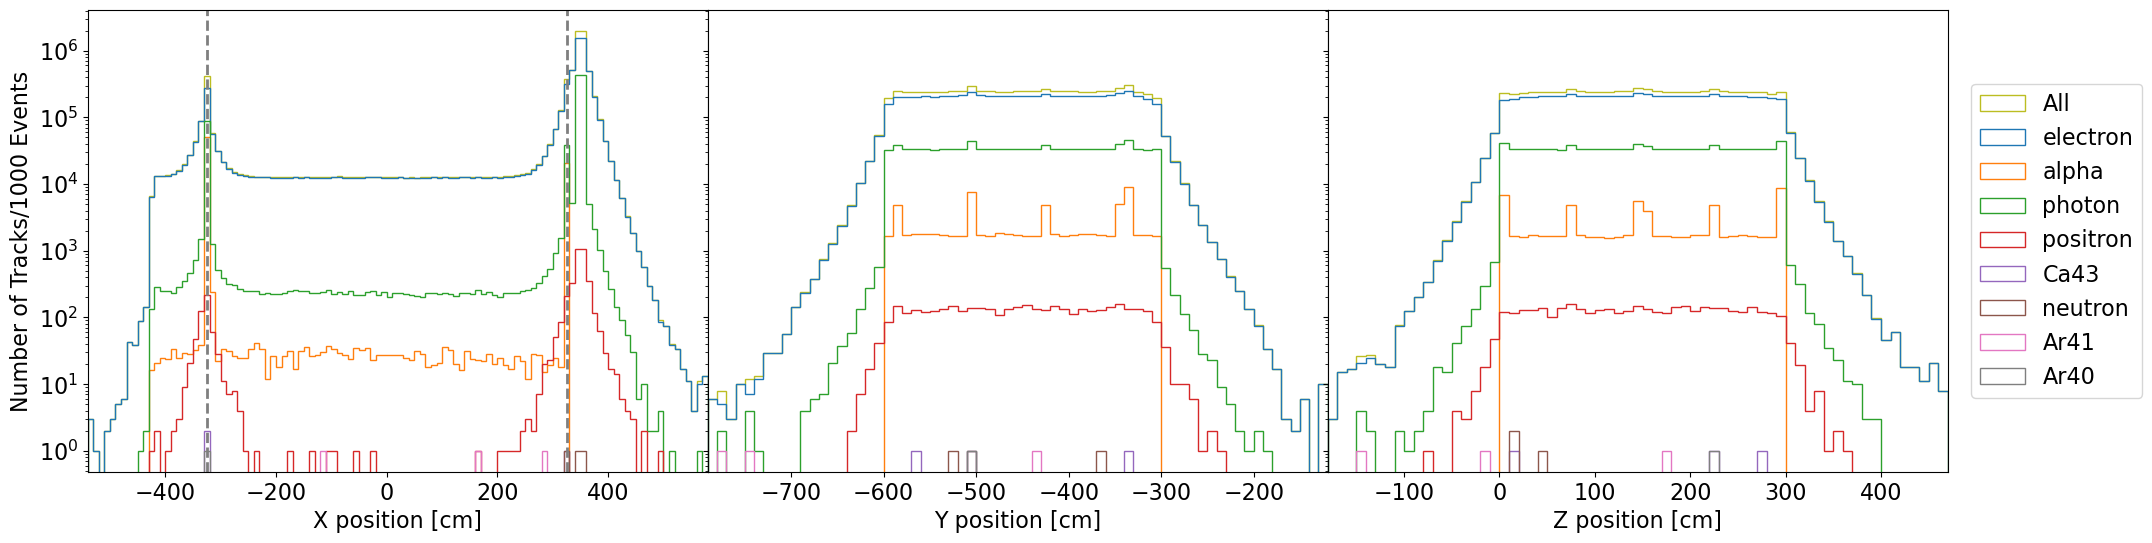

In [23]:
fig, ax = plt.subplots(1, 3, figsize = (24, 6), sharey = True)
fig.subplots_adjust(wspace = 0)  # remove gaps between panels

xbins = np.linspace(-540, 580, 113)
ybins = np.linspace(-790, -120, 68)
zbins = np.linspace(-180, 470, 66)

fonts = 16

## X
ax[0].hist(dT['xyz_start'].str[0], bins = xbins, histtype = 'step', label = 'All', color = colorAll)
for radMap in pdgDF.itertuples(index = False):
    ax[0].hist(dT.loc[dT['pdg_id'].eq(radMap.pdgCode), 'xyz_start'].str[0], bins = xbins, histtype = 'step',
               color = radMap.color, label = radMap.name)

ax[0].axvline(x = -325, color = "tab:grey", linestyle = "--", linewidth = 2) 
ax[0].axvline(x = 325, color = "tab:grey", linestyle = "--", linewidth = 2) 

ax[0].set_xlabel('X position [cm]', fontsize = fonts)
ax[0].set_ylabel('Number of Tracks/1000 Events', fontsize = fonts)
ax[0].set_xlim([-540, 580])

## Y
ax[1].hist(dT['xyz_start'].str[1], bins = ybins, histtype = 'step', label = 'All', color = colorAll)
for radMap in pdgDF.itertuples(index = False):
    ax[1].hist(dT.loc[dT['pdg_id'].eq(radMap.pdgCode), 'xyz_start'].str[1], bins = ybins, histtype = 'step',
               color = radMap.color, label = radMap.name)

ax[1].set_xlabel('Y position [cm]', fontsize = fonts)
ax[1].set_xlim([-790, -120])

## Z
ax[2].hist(dT['xyz_start'].str[2], bins = zbins, histtype = 'step', label = 'All', color = colorAll)
for radMap in pdgDF.itertuples(index = False):
    ax[2].hist(dT.loc[dT['pdg_id'].eq(radMap.pdgCode), 'xyz_start'].str[2], bins = zbins, histtype = 'step',
               color = radMap.color, label = radMap.name)

ax[2].set_xlabel('Z position [cm]', fontsize = fonts)
ax[2].set_xlim([-180, 470])

## Common
for i in range(3):
    ax[i].tick_params(axis = "both", labelsize = fonts)
    ax[i].set_yscale('log')

ax[2].legend(loc = "center left", bbox_to_anchor = (1.02, 0.5), fontsize = fonts)

X, Y, Z of the track starting points - zoom in, 1cm/bin

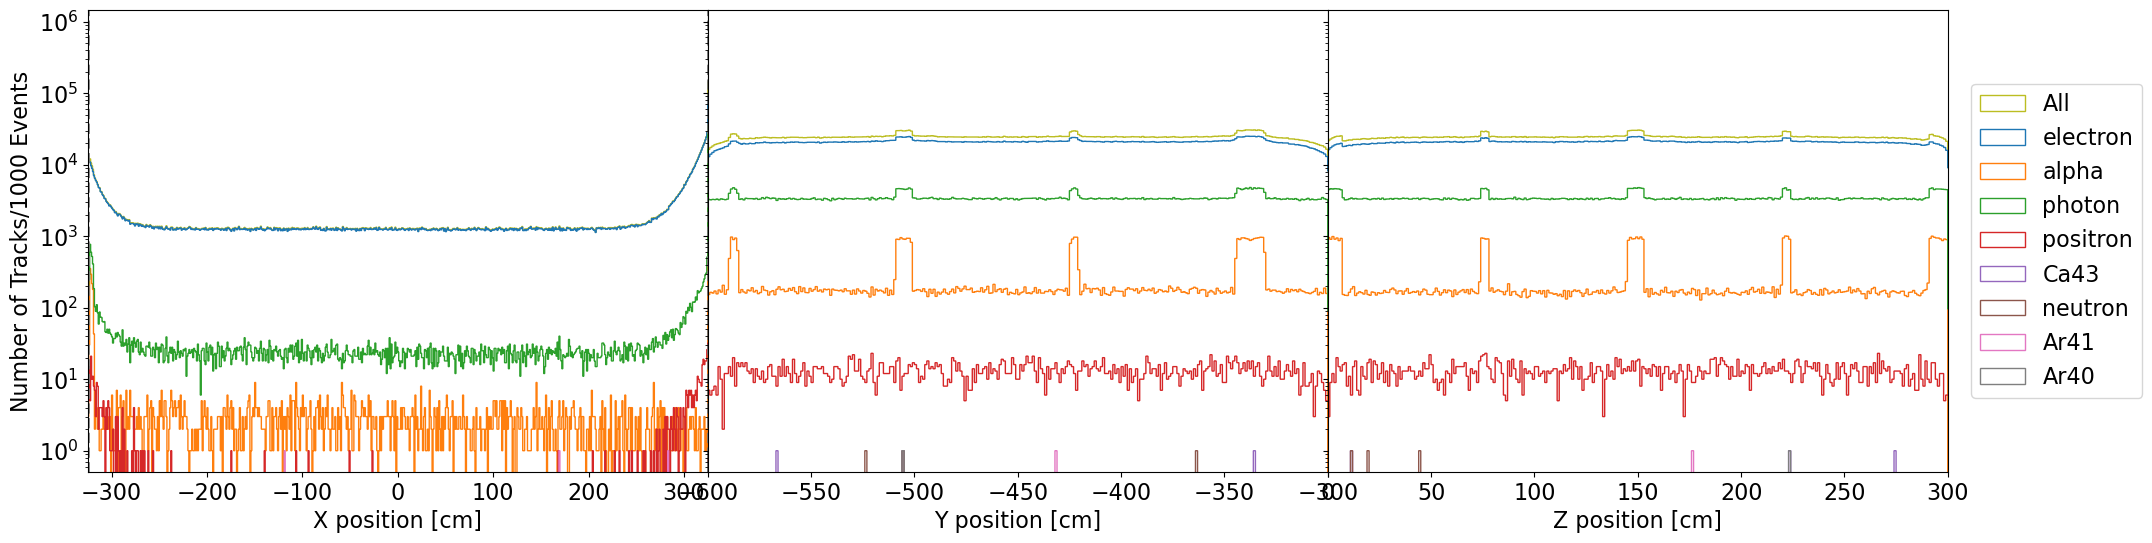

In [24]:
fig, ax = plt.subplots(1, 3, figsize = (24, 6), sharey = True)
fig.subplots_adjust(wspace = 0)  # remove gaps between panels

xbins = np.linspace(-540, 580, 1121)
ybins = np.linspace(-790, -120, 671)
zbins = np.linspace(-180, 470, 651)

fonts = 16

## X
ax[0].hist(dT['xyz_start'].str[0], bins = xbins, histtype = 'step', label = 'All', color = colorAll)
for radMap in pdgDF.itertuples(index = False):
    ax[0].hist(dT.loc[dT['pdg_id'].eq(radMap.pdgCode), 'xyz_start'].str[0], bins = xbins, histtype = 'step',
               color = radMap.color, label = radMap.name)

ax[0].axvline(x = -325, color = "tab:grey", linestyle = "--", linewidth = 2) 
ax[0].axvline(x = 325, color = "tab:grey", linestyle = "--", linewidth = 2) 

ax[0].set_xlabel('X position [cm]', fontsize = fonts)
ax[0].set_ylabel('Number of Tracks/1000 Events', fontsize = fonts)
ax[0].set_xlim([-325, 325])

## Y
ax[1].hist(dT['xyz_start'].str[1], bins = ybins, histtype = 'step', label = 'All', color = colorAll)
for radMap in pdgDF.itertuples(index = False):
    ax[1].hist(dT.loc[dT['pdg_id'].eq(radMap.pdgCode), 'xyz_start'].str[1], bins = ybins, histtype = 'step',
               color = radMap.color, label = radMap.name)

ax[1].set_xlabel('Y position [cm]', fontsize = fonts)
ax[1].set_xlim([-600, -300])

## Z
ax[2].hist(dT['xyz_start'].str[2], bins = zbins, histtype = 'step', label = 'All', color = colorAll)
for radMap in pdgDF.itertuples(index = False):
    ax[2].hist(dT.loc[dT['pdg_id'].eq(radMap.pdgCode), 'xyz_start'].str[2], bins = zbins, histtype = 'step',
               color = radMap.color, label = radMap.name)

ax[2].set_xlabel('Z position [cm]', fontsize = fonts)
ax[2].set_xlim([0, 300])

## Common
for i in range(3):
    ax[i].tick_params(axis = "both", labelsize = fonts)
    ax[i].set_yscale('log')

ax[2].legend(loc = "center left", bbox_to_anchor = (1.02, 0.5), fontsize = fonts)


X, Y, Z of the track starting points - further zoom in, 5mm/bin

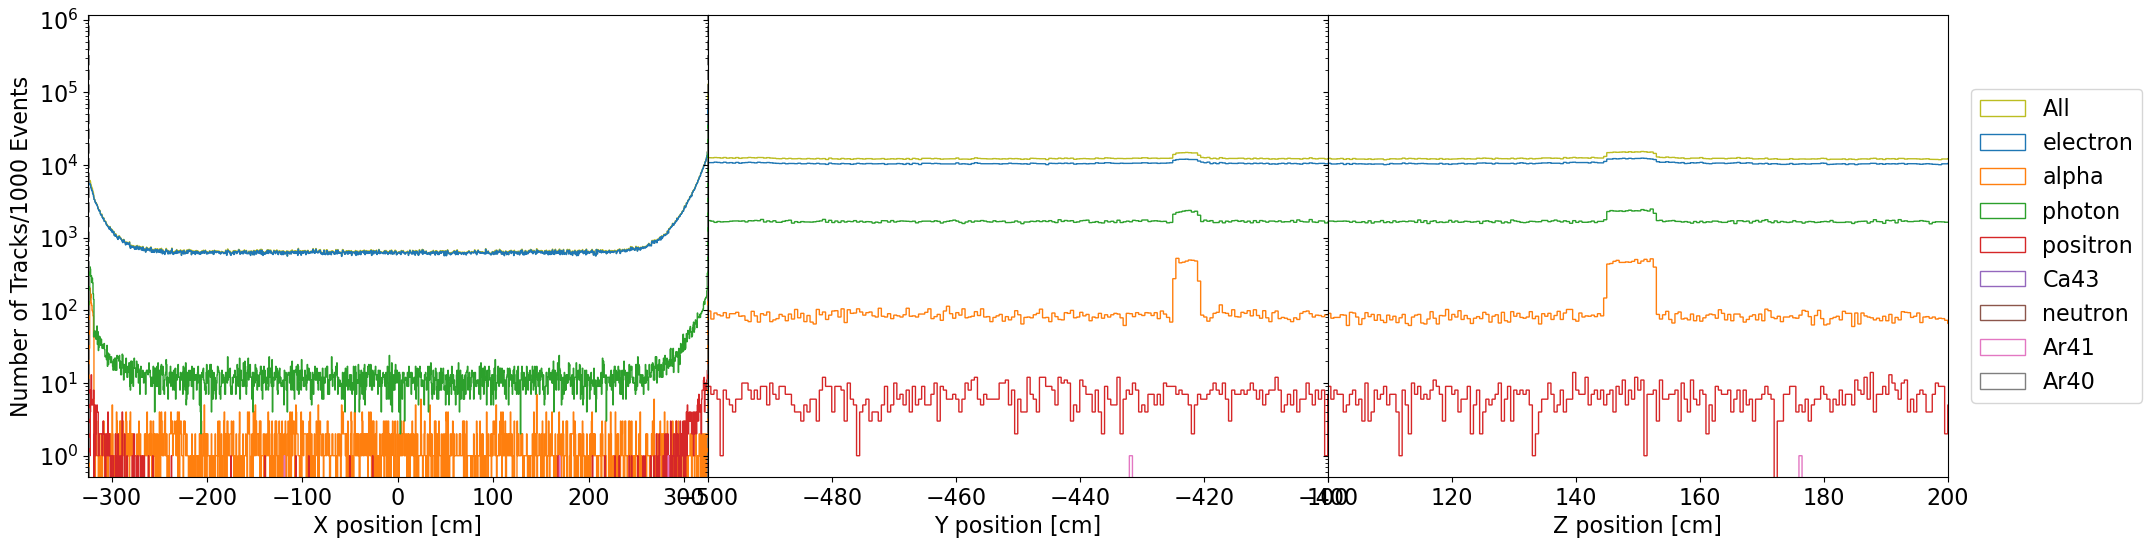

In [25]:
fig, ax = plt.subplots(1, 3, figsize = (24, 6), sharey = True)
fig.subplots_adjust(wspace = 0)  # remove gaps between panels

xbins = np.linspace(-1400, 560, 3921)
ybins = np.linspace(-330, 330, 1321)
zbins = np.linspace(720, 1370, 1301)

xbins = np.linspace(-540, 580, 2241)
ybins = np.linspace(-790, -120, 1341)
zbins = np.linspace(-180, 470, 1301)

fonts = 16

## X
ax[0].hist(dT['xyz_start'].str[0], bins = xbins, histtype = 'step', label = 'All', color = colorAll)
for radMap in pdgDF.itertuples(index = False):
    ax[0].hist(dT.loc[dT['pdg_id'].eq(radMap.pdgCode), 'xyz_start'].str[0], bins = xbins, histtype = 'step',
               color = radMap.color, label = radMap.name)

ax[0].axvline(x = -325, color = "tab:grey", linestyle = "--", linewidth = 2) 
ax[0].axvline(x = 325, color = "tab:grey", linestyle = "--", linewidth = 2) 

ax[0].set_xlabel('X position [cm]', fontsize = fonts)
ax[0].set_ylabel('Number of Tracks/1000 Events', fontsize = fonts)
ax[0].set_xlim([-325, 325])

## Y
ax[1].hist(dT['xyz_start'].str[1], bins = ybins, histtype = 'step', label = 'All', color = colorAll)
for radMap in pdgDF.itertuples(index = False):
    ax[1].hist(dT.loc[dT['pdg_id'].eq(radMap.pdgCode), 'xyz_start'].str[1], bins = ybins, histtype = 'step',
               color = radMap.color, label = radMap.name)

ax[1].set_xlabel('Y position [cm]', fontsize = fonts)
ax[1].set_xlim([-500, -400])

## Z
ax[2].hist(dT['xyz_start'].str[2], bins = zbins, histtype = 'step', label = 'All', color = colorAll)
for radMap in pdgDF.itertuples(index = False):
    ax[2].hist(dT.loc[dT['pdg_id'].eq(radMap.pdgCode), 'xyz_start'].str[2], bins = zbins, histtype = 'step',
               color = radMap.color, label = radMap.name)

ax[2].set_xlabel('Z position [cm]', fontsize = fonts)
ax[2].set_xlim([100, 200])

## Common
for i in range(3):
    ax[i].tick_params(axis = "both", labelsize = fonts)
    ax[i].set_yscale('log')

ax[2].legend(loc = "center left", bbox_to_anchor = (1.02, 0.5), fontsize = fonts)

## Time

In [26]:
dT.t_start.min(), dT.t_start.max()

(-4284.997956752777, 5452.94553792746)

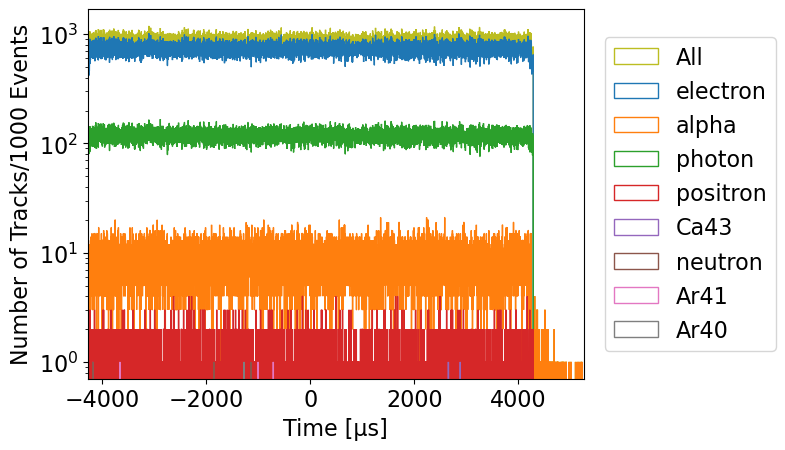

In [27]:
fig, ax = plt.subplots()

tBins = np.linspace(-4285, 5255, 9741)
fonts = 16

ax.hist(dT['t_start'], bins = tBins, histtype = 'step', label = 'All', color = colorAll)
for ip in pdgDF.itertuples( index = False ):
    mask = dT["pdg_id"].eq(ip.pdgCode)
    ax.hist(dT[mask].t_start, bins = tBins, histtype = 'step', # alpha = 0.35,
            color = ip.color, label = ip.name)

ax.set_xlabel('Time [µs]', fontsize = fonts)
ax.tick_params(axis = "both", labelsize = fonts)
ax.set_yscale('log')

ax.set_ylabel('Number of Tracks/1000 Events', fontsize = fonts)
ax.set_xlim([-4285, 5255])
ax.legend(loc = "center left", bbox_to_anchor = (1.02, 0.5), fontsize = fonts)

## TrackID

Pick photons as examples

In [ ]:
dT[(dT.parent_id==-1)&(dT.pdg_id==22)]

,event_id,vertex_id,file_vertex_id,traj_id,file_traj_id,parent_id,primary,E_start,pxyz_start,xyz_start,...,E_end,pxyz_end,xyz_end,t_end,pdg_id,start_process,start_subprocess,end_process,end_subprocess,dist_travel
886,0,886,886,886,886,-1,True,0.016000,"[0.012111194431781769, 0.009546907618641853, 0...","[12.136786460876465, -557.541259765625, 35.245...",...,1.491396e-10,"[0.0, 0.0, 0.0]","[12.15431022644043, -557.5274658203125, 35.251...",-2505.336791,22,0,0,2,12,0.023150
888,0,888,888,888,888,-1,True,0.003000,"[0.0024798368103802204, 0.0005083452560938895,...","[-328.7908020019531, -334.61163330078125, 62.3...",...,1.211167e-11,"[0.0, 0.0, 0.0]","[-328.78546142578125, -334.61053466796875, 62....",3070.472360,22,0,0,2,12,0.006481
889,0,889,889,889,889,-1,True,1.461000,"[-0.9824210405349731, 0.4488113820552826, 0.98...","[-328.7908020019531, -334.61163330078125, 62.3...",...,1.056214e-08,"[-0.0, -0.0, -0.0]","[-326.3138427734375, -325.292724609375, 60.140...",3070.473432,22,0,0,2,12,32.109734
900,0,900,900,900,900,-1,True,0.093000,"[-0.08123650401830673, 0.043550044298172, 0.01...","[-326.1532897949219, -534.3186645507812, 75.59...",...,5.338485e-10,"[-0.0, 0.0, -0.0]","[-335.39434814453125, -530.4596557617188, 74.5...",2460.745705,22,0,0,2,12,10.160780
903,0,903,903,903,903,-1,True,0.021000,"[0.014353673905134201, -0.001501842518337071, ...","[-327.26947021484375, -587.9244384765625, 257....",...,1.984744e-10,"[0.0, -0.0, 0.0]","[-327.216552734375, -587.9299926757812, 257.09...",-2902.069953,22,0,0,2,12,0.077419
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7543298,999,2032,2092310,2032,7543298,-1,True,1.125084,"[0.1488502323627472, 1.093430995941162, -0.219...","[349.73187255859375, -460.43658447265625, 118....",...,1.391020e-08,"[-0.0, 0.0, -0.0]","[430.370361328125, -424.71893310546875, 151.27...",400.158488,22,2,13,2,12,130.536179
7543299,999,2033,2092311,2033,7543299,-1,True,1.461040,"[0.7247321009635925, 0.8350902795791626, 0.955...","[349.9254455566406, -432.6017761230469, 106.73...",...,1.246824e-08,"[0.0, -0.0, 0.0]","[352.17327880859375, -431.92449951171875, 127....",4207.793800,22,2,2,2,12,44.116028
7543300,999,2034,2092312,2034,7543300,-1,True,0.095827,"[-0.08965893089771271, -0.0024366427678614855,...","[350.2034912109375, -566.2717895507812, 91.697...",...,1.000563e-09,"[-0.0, 0.0, 0.0]","[340.0476379394531, -557.853271484375, 83.6435...",-1300.933411,22,2,2,2,12,16.899242
7543301,999,2035,2092313,2035,7543301,-1,True,0.165214,"[-0.1496068835258484, 0.011887798085808754, 0....","[350.4615783691406, -493.8741760253906, 168.74...",...,2.118406e-10,"[0.0, -0.0, -0.0]","[342.9958801269531, -492.93975830078125, 178.2...",2928.798223,22,2,13,2,12,15.056442


In [ ]:
dT[(dT.event_id==0)&(dT.traj_id==889)]

,event_id,vertex_id,file_vertex_id,traj_id,file_traj_id,parent_id,primary,E_start,pxyz_start,xyz_start,...,E_end,pxyz_end,xyz_end,t_end,pdg_id,start_process,start_subprocess,end_process,end_subprocess,dist_travel
889,0,889,889,889,889,-1,True,1.461,"[-0.9824210405349731, 0.4488113820552826, 0.98...","[-328.7908020019531, -334.61163330078125, 62.3...",...,1.056214e-08,"[-0.0, -0.0, -0.0]","[-326.3138427734375, -325.292724609375, 60.140...",3070.473432,22,0,0,2,12,32.109734


In [32]:
dT[(dT.event_id==0)&(dT.parent_id==889)]

,event_id,vertex_id,file_vertex_id,traj_id,file_traj_id,parent_id,primary,E_start,pxyz_start,xyz_start,...,E_end,pxyz_end,xyz_end,t_end,pdg_id,start_process,start_subprocess,end_process,end_subprocess,dist_travel
8145,0,889,889,8152,8152,889,False,0.590639,"[-0.18614616990089417, -0.07148665934801102, -...","[-326.3138427734375, -325.292724609375, 60.140...",...,0.510999,"[-0.0, -0.0, -0.0]","[-326.3155212402344, -325.2933654785156, 60.13...",3070.473432,11,2,12,2,22,0.002702
8146,0,889,889,8151,8151,889,False,0.545804,"[0.13019712269306183, 0.13793015480041504, 0.0...","[-324.8595275878906, -324.3790588378906, 60.87...",...,0.510999,"[0.0, 0.0, 0.0]","[-324.8591003417969, -324.37860107421875, 60.8...",3070.473369,11,2,13,2,22,0.000636
8147,0,889,889,8150,8150,889,False,0.524471,"[0.04995015636086464, -0.09058313071727753, -0...","[-326.2267150878906, -326.4052429199219, 60.96...",...,0.510999,"[0.0, -0.0, -0.0]","[-326.2266540527344, -326.40533447265625, 60.9...",3070.473288,11,2,13,2,22,0.000120
8148,0,889,889,8149,8149,889,False,0.602336,"[-0.1965782195329666, 0.1386806070804596, 0.20...","[-336.1653137207031, -327.0274353027344, 66.34...",...,0.510999,"[-0.0, 0.0, 0.0]","[-336.1674499511719, -327.02593994140625, 66.3...",3070.472910,11,2,13,2,22,0.003421
8149,0,889,889,8148,8148,889,False,0.570763,"[-0.051227182149887085, 0.0871763601899147, -0...","[-335.79913330078125, -327.6815490722656, 65.6...",...,0.510999,"[-0.0, 0.0, -0.0]","[-335.7994689941406, -327.6809997558594, 65.68...",3070.472877,11,2,13,2,22,0.001642
8150,0,889,889,8147,8147,889,False,0.850383,"[-0.2844957709312439, -0.2928158640861511, 0.5...","[-331.89410400390625, -334.5301513671875, 68.2...",...,0.510999,"[-0.0, 0.0, -0.0]","[-331.9064025878906, -334.5426940917969, 68.26...",3070.472602,11,2,13,2,22,0.029286
8151,0,889,889,8146,8146,889,False,0.682075,"[0.31339138746261597, -0.05354420468211174, 0....","[-330.7485046386719, -334.36669921875, 66.9852...",...,0.510999,"[0.0, -0.0, 0.0]","[-330.7416687011719, -334.36785888671875, 66.9...",3070.472544,11,2,13,2,22,0.009847
8152,0,889,889,8145,8145,889,False,1.179341,"[-0.8783171772956848, 0.5619202852249146, 0.20...","[-330.3277282714844, -333.9095153808594, 63.84...",...,0.510999,"[0.0, -0.0, -0.0]","[-330.3792724609375, -333.87554931640625, 63.8...",3070.472441,11,2,13,2,22,0.062009


In [35]:
dT[(dT.parent_id==-1)&(dT.pdg_id==22)&(dT.dist_travel>80)]

,event_id,vertex_id,file_vertex_id,traj_id,file_traj_id,parent_id,primary,E_start,pxyz_start,xyz_start,...,E_end,pxyz_end,xyz_end,t_end,pdg_id,start_process,start_subprocess,end_process,end_subprocess,dist_travel
940,0,940,940,940,940,-1,True,1.509000,"[-0.3131049573421478, -1.448441505432129, -0.2...","[-328.4092102050781, -588.095703125, 6.2279839...",...,1.488756e-08,"[-0.0, -0.0, -0.0]","[-377.89007568359375, -590.0668334960938, 22.9...",1691.808609,22,0,0,2,12,123.218262
1070,0,1070,1070,1070,1070,-1,True,0.969000,"[0.32190391421318054, 0.8303694128990173, -0.3...","[-328.7796936035156, -439.124755859375, 294.44...",...,3.473729e-09,"[-0.0, 0.0, -0.0]","[-275.6678161621094, -416.3621520996094, 303.5...",-4208.570333,22,0,0,2,12,83.047035
1072,0,1072,1072,1072,1072,-1,True,0.338000,"[-0.27136340737342834, -0.03183536231517792, 0...","[-326.7569580078125, -586.0549926757812, 229.2...",...,4.120811e-09,"[0.0, -0.0, -0.0]","[-354.1796875, -590.9469604492188, 220.1148376...",1300.867975,22,0,0,2,12,81.310867
1177,0,1177,1177,1177,1177,-1,True,2.615000,"[-0.02467399090528488, 2.321730852127075, -1.2...","[-326.7305603027344, -585.9114990234375, 141.9...",...,2.594001e-08,"[-0.0, -0.0, 0.0]","[-343.7126770019531, -539.3446044921875, 137.0...",486.262152,22,0,0,2,12,105.031654
1237,0,1237,1237,1237,1237,-1,True,1.496000,"[0.2956363558769226, -1.3651078939437866, -0.5...","[325.0870361328125, -512.21142578125, 179.9068...",...,1.537014e-08,"[-0.0, 0.0, 0.0]","[305.7210388183594, -566.1787109375, 203.75819...",-844.886976,22,0,0,2,12,97.759056
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7543246,999,1980,2092258,1980,7543246,-1,True,1.517642,"[0.3800485134124756, -0.0990368202328682, -1.4...","[350.4873046875, -421.418212890625, 43.7705497...",...,1.390423e-08,"[0.0, 0.0, 0.0]","[375.67572021484375, -435.4416809082031, -26.3...",2504.218518,22,2,2,2,12,104.439178
7543247,999,1981,2092259,1981,7543247,-1,True,0.756104,"[0.7100223302841187, 0.23530668020248413, 0.11...","[350.1765441894531, -468.8424377441406, 7.8616...",...,6.309504e-09,"[0.0, 0.0, -0.0]","[374.00628662109375, -449.2265625, 54.54973983...",3189.216756,22,2,2,2,12,107.952637
7543281,999,2015,2092293,2015,7543281,-1,True,1.123237,"[-0.5437681078910828, 0.13764411211013794, 0.9...","[349.5621643066406, -412.9227600097656, 18.672...",...,1.125545e-08,"[0.0, -0.0, 0.0]","[321.3636169433594, -438.80731201171875, 53.87...",771.990123,22,2,22,2,12,83.792084
7543287,999,2021,2092299,2021,7543287,-1,True,1.181170,"[-0.17683593928813934, -1.0864243507385254, 0....","[349.57305908203125, -322.8135986328125, 262.8...",...,2.937512e-09,"[0.0, -0.0, 0.0]","[354.1816711425781, -369.0096435546875, 277.64...",-868.189883,22,2,12,2,12,81.518135


In [34]:
dT[(dT.event_id==0)&(dT.parent_id==940)]

,event_id,vertex_id,file_vertex_id,traj_id,file_traj_id,parent_id,primary,E_start,pxyz_start,xyz_start,...,E_end,pxyz_end,xyz_end,t_end,pdg_id,start_process,start_subprocess,end_process,end_subprocess,dist_travel
8113,0,940,940,8125,8125,940,False,0.594285,"[-0.16760686039924622, 0.24721142649650574, -0...","[-377.89007568359375, -590.0668334960938, 22.9...",...,0.510999,"[-0.0, 0.0, -0.0]","[-377.89166259765625, -590.064453125, 22.96358...",1691.808609,11,2,12,2,22,0.002919
8114,0,940,940,8124,8124,940,False,0.515401,"[0.05970276519656181, -0.026601416990160942, 0...","[-376.6408996582031, -588.4902954101562, 27.27...",...,0.510999,"[0.0, -0.0, 0.0]","[-376.6408996582031, -588.4903564453125, 27.27...",1691.808449,11,2,13,2,22,0.000018
8115,0,940,940,8123,8123,940,False,0.525283,"[-0.008252429775893688, -0.02886308915913105, ...","[-378.6439514160156, -585.3663940429688, 30.74...",...,0.510999,"[-0.0, -0.0, 0.0]","[-378.6439514160156, -585.366455078125, 30.748...",1691.808280,11,2,13,2,22,0.000133
8116,0,940,940,8122,8122,940,False,0.517944,"[0.06765654683113098, 0.027028191834688187, -0...","[-379.2375793457031, -583.5419921875, 29.54593...",...,0.510999,"[0.0, 0.0, -0.0]","[-379.237548828125, -583.5419311523438, 29.545...",1691.808204,11,2,13,2,22,0.000038
8117,0,940,940,8121,8121,940,False,0.565588,"[-0.2387295961380005, -0.0072591411881148815, ...","[-382.228515625, -581.7296142578125, 29.138719...",...,0.510999,"[-0.0, -0.0, 0.0]","[-382.2298889160156, -581.7296752929688, 29.13...",1691.808087,11,2,13,2,22,0.001402
8118,0,940,940,8120,8120,940,False,0.515698,"[-0.02230830118060112, 0.022252151742577553, -...","[-374.417724609375, -578.1939086914062, 26.172...",...,0.510999,"[-0.0, 0.0, -0.0]","[-374.4177551269531, -578.1939086914062, 26.17...",1691.807784,11,2,13,2,22,0.000020
8119,0,940,940,8119,8119,940,False,0.556494,"[0.04006992653012276, 0.18734851479530334, 0.1...","[-363.51068115234375, -575.3845825195312, 26.6...",...,0.510999,"[0.0, 0.0, 0.0]","[-363.510498046875, -575.3836669921875, 26.659...",1691.807408,11,2,13,2,22,0.001018
8120,0,940,940,8118,8118,940,False,0.524143,"[-0.048437073826789856, 0.005534234456717968, ...","[-355.775390625, -584.2823486328125, 20.413948...",...,0.510999,"[-0.0, 0.0, -0.0]","[-355.77545166015625, -584.2823486328125, 20.4...",1691.806963,11,2,13,2,22,0.000115
8121,0,940,940,8117,8117,940,False,0.512957,"[-0.010498173534870148, -0.014214248396456242,...","[-337.35479736328125, -600.227294921875, 20.93...",...,0.510999,"[-0.0, -0.0, 0.0]","[-337.35479736328125, -600.227294921875, 20.93...",1691.806150,11,2,13,2,22,0.000005
8122,0,940,940,8116,8116,940,False,0.530113,"[0.10280172526836395, 0.0906016156077385, 0.03...","[-334.2879638671875, -602.5061645507812, 20.34...",...,0.510999,"[0.0, 0.0, 0.0]","[-334.2878112792969, -602.5059814453125, 20.34...",1691.806021,11,2,13,2,22,0.000221


In [36]:
photon = dT[(dT.event_id==0)&(dT.traj_id==940)]
secondaries = dT[(dT.event_id==0)&(dT.parent_id==940)]

In [44]:
detector_bounds = [[-390, -320], [-600, -300], [-400, 50]] # cm (x, y, z)
def draw_boundaries(ax):
    """
    Draw the detector boundaries as a wireframe
    not needed, but pretty
    """
    boundKwargs = {'color': 'black',
                   'ls': '--'}
    
    ax.plot([detector_bounds[0][0], detector_bounds[0][1]],
            [detector_bounds[1][0], detector_bounds[1][0]],
            [detector_bounds[2][0], detector_bounds[2][0]],
            **boundKwargs)
    ax.plot([detector_bounds[0][0], detector_bounds[0][1]],
            [detector_bounds[1][1], detector_bounds[1][1]],
            [detector_bounds[2][0], detector_bounds[2][0]],
            **boundKwargs)
    ax.plot([detector_bounds[0][0], detector_bounds[0][1]],
            [detector_bounds[1][0], detector_bounds[1][0]],
            [detector_bounds[2][1], detector_bounds[2][1]],
            **boundKwargs)
    ax.plot([detector_bounds[0][0], detector_bounds[0][1]],
            [detector_bounds[1][1], detector_bounds[1][1]],
            [detector_bounds[2][1], detector_bounds[2][1]],
            **boundKwargs)

    ax.plot([detector_bounds[0][0], detector_bounds[0][0]],
            [detector_bounds[1][0], detector_bounds[1][1]],
            [detector_bounds[2][0], detector_bounds[2][0]],
            **boundKwargs)
    ax.plot([detector_bounds[0][1], detector_bounds[0][1]],
            [detector_bounds[1][0], detector_bounds[1][1]],
            [detector_bounds[2][0], detector_bounds[2][0]],
            **boundKwargs)
    ax.plot([detector_bounds[0][0], detector_bounds[0][0]],
            [detector_bounds[1][0], detector_bounds[1][1]],
            [detector_bounds[2][1], detector_bounds[2][1]],
            **boundKwargs)
    ax.plot([detector_bounds[0][1], detector_bounds[0][1]],
            [detector_bounds[1][0], detector_bounds[1][1]],
            [detector_bounds[2][1], detector_bounds[2][1]],
            **boundKwargs)

    ax.plot([detector_bounds[0][0], detector_bounds[0][0]],
            [detector_bounds[1][0], detector_bounds[1][0]],
            [detector_bounds[2][0], detector_bounds[2][1]],
            **boundKwargs)
    ax.plot([detector_bounds[0][0], detector_bounds[0][0]],
            [detector_bounds[1][1], detector_bounds[1][1]],
            [detector_bounds[2][0], detector_bounds[2][1]],
            **boundKwargs)
    ax.plot([detector_bounds[0][1], detector_bounds[0][1]],
            [detector_bounds[1][0], detector_bounds[1][0]],
            [detector_bounds[2][0], detector_bounds[2][1]],
            **boundKwargs)
    ax.plot([detector_bounds[0][1], detector_bounds[0][1]],
            [detector_bounds[1][1], detector_bounds[1][1]],
            [detector_bounds[2][0], detector_bounds[2][1]],
            **boundKwargs)

    return ax

(-402.0, 52.0)

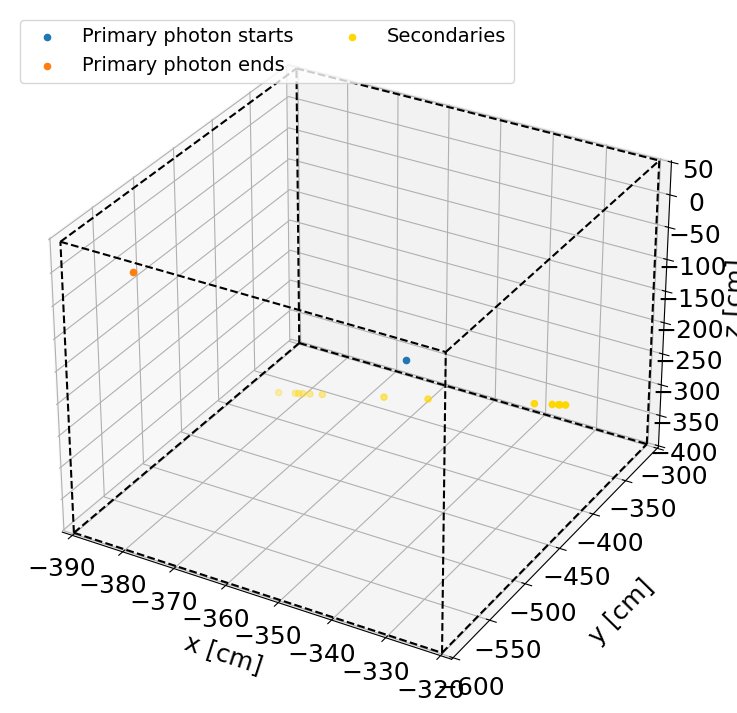

In [50]:
fig = plt.figure( figsize = (9, 9))  
ax = fig.add_subplot( 1, 1, 1, projection = '3d' )

ax.scatter( photon.xyz_start.str[0], photon.xyz_start.str[1], photon.xyz_start.str[2], label = 'Primary photon starts')
ax.scatter( photon.xyz_end.str[0], photon.xyz_end.str[1], photon.xyz_end.str[2], label = 'Primary photon ends')
ax.scatter( secondaries.xyz_start.str[0], secondaries.xyz_start.str[0], secondaries.xyz_start.str[0], c = 'gold', label = 'Secondaries')
                    
draw_boundaries(ax)
ax.set_xlabel('x [cm]', fontsize = 18, labelpad = 10)
ax.set_ylabel('y [cm]', fontsize = 18, labelpad = 20)
ax.set_zlabel('z [cm]', fontsize = 18, labelpad = 10)
ax.tick_params( axis = 'x', labelsize = 18 )
ax.tick_params( axis = 'y', labelsize = 18 )
ax.tick_params( axis = 'z', labelsize = 18 )
ax.legend( ncol = 2, fontsize = 14, loc = 'upper left' )
ax.set_xlim( [-392, -318])
ax.set_ylim( [-602, -298])
ax.set_zlim( [-402, 52])
# fig.subplots_adjust( right = 0.9)

In [38]:
photon.xyz_start

940    [-328.4092102050781, -588.095703125, 6.2279839...
Name: xyz_start, dtype: object

In [40]:
photon.xyz_start.str[0]

940   -328.40921
Name: xyz_start, dtype: float64

In [43]:
np.sqrt((photon.xyz_end.str[0]-photon.xyz_start.str[0])**2 + (photon.xyz_end.str[1]-photon.xyz_start.str[1])**2 + (photon.xyz_end.str[2]-photon.xyz_start.str[2])**2)

940    52.271779
dtype: float64

In this example, Event ID = 0, Traj ID = 940, the primary photon's travel distance, according to the G4 output, is 123.218262cm, while the straight line between the starting and ending points is 52.271779cm.

It creates electrons via atom de-excitation and synchrotron radiation, as plotted above - the gold points are the starting points of these electrons.  All the electrons have low kinetic energy and the travel distances are short.

This study confirms that the (primary) photon has the same traj ID (track ID) before and after creating secondary electrons.  And it explains why we see long photon G4 tracks, and why the photon G4 tracks can deposit so much energy.